<a href="https://colab.research.google.com/github/SattamAltwaim/StarX/blob/main/experiments/09_synthetic_sketches.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Setup: clone the StarX repo and the pinned TripoSR commit, install this
# notebook's dependencies, mount Drive, and report what machine we are on.
import os
import subprocess
import sys

BRANCH = "main"
TRIPOSR_COMMIT = "107cefdc244c39106fa830359024f6a2f1c78871"
NOTEBOOK_ID = "09"

IN_COLAB = os.path.exists("/content")
if IN_COLAB:
    REPO_DIR = "/content/StarX"
    if not os.path.exists(REPO_DIR):
        subprocess.run(
            ["git", "clone", "--branch", BRANCH,
             "https://github.com/SattamAltwaim/StarX.git", REPO_DIR],
            check=True,
        )
    TRIPOSR_DIR = "/content/TripoSR"
else:
    # off Colab the kernel's cwd is unpredictable (VS Code often starts in
    # $HOME) - walk up from the notebook location and the cwd to find the
    # repo, with ~/StarX as the final fallback
    def _find_repo():
        candidates = [globals().get("__vsc_ipynb_file__"), os.getcwd()]
        for start in candidates:
            if not start:
                continue
            path = os.path.abspath(
                os.path.dirname(start) if os.path.isfile(start) else start
            )
            while path != os.path.dirname(path):
                if os.path.exists(os.path.join(path, "starx", "pins.py")):
                    return path
                path = os.path.dirname(path)
        home_repo = os.path.join(os.path.expanduser("~"), "StarX")
        if os.path.exists(os.path.join(home_repo, "starx", "pins.py")):
            return home_repo
        raise RuntimeError(
            "could not locate the StarX repo - start Jupyter inside it "
            "or clone it to ~/StarX"
        )

    REPO_DIR = _find_repo()
    TRIPOSR_DIR = os.path.join(REPO_DIR, "third_party", "TripoSR")
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

if not os.path.exists(TRIPOSR_DIR):
    subprocess.run(
        ["git", "clone", "https://github.com/VAST-AI-Research/TripoSR.git",
         TRIPOSR_DIR],
        check=True,
    )
subprocess.run(["git", "-C", TRIPOSR_DIR, "checkout", "-q", TRIPOSR_COMMIT], check=True)

from starx import pins

assert pins.TRIPOSR_COMMIT == TRIPOSR_COMMIT, "notebook pin out of sync with starx/pins.py"
if pins.PIP_PINS[NOTEBOOK_ID]:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", *pins.PIP_PINS[NOTEBOOK_ID]],
        check=True,
    )
# remove Colab preinstalls that break the pinned stack (see starx/pins.py)
if IN_COLAB and pins.PIP_UNINSTALL.get(NOTEBOOK_ID):
    subprocess.run(
        [sys.executable, "-m", "pip", "uninstall", "-q", "-y",
         *pins.PIP_UNINSTALL[NOTEBOOK_ID]],
        check=False, capture_output=True,
    )

from starx import colab as scolab

DRIVE = scolab.mount_drive()
report = scolab.setup_report()

Mounted at /content/drive
        python: 3.12.13
         torch: 2.11.0+cu128
cuda_available: True
           gpu: Tesla T4
       vram_gb: 14.6
  disk_free_gb: 65.7
     cpu_count: 2
      in_colab: True


# 09 - Synthetic sketches, stock TripoSR

A second route to the same goal, deliberately plainer than the baseline.

Notebook 03 already rendered every design from many camera positions. This notebook turns each of those renders into a line drawing with classical convolutional edge detection - a Gaussian blur, a Sobel gradient, a contrast curve - and fine-tunes TripoSR on those drawings the ordinary way: three input channels, one image in, no surgery on the network at all.

The trade is explicit. The drawings are not the design's real CAD sketches, so this is a weaker claim about sketch-to-3D. In exchange the input is exactly the kind of picture the checkpoint was pretrained on, the data is free and unlimited (one design yields as many training pairs as it has views), and the model is stock - which makes it the clean control for the baseline run.

The steps:

1. read the posed renders that notebook 03 already stored,
2. build the edge-detection pipeline one convolution at a time and look at every intermediate,
3. rotate each design's cameras so the input view becomes the front, which is the frame TripoSR predicts in,
4. load the pretrained model untouched and see what it already does with a drawing,
5. fine-tune it with the same rendering loss, the same loop, and the same resumable checkpoints as notebook 05.

Runs after notebook 03; needs no new preprocessing and no rebuilt shards.

In [2]:
# Configuration - every tunable for this notebook lives here.
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm

from starx import cameras, checkpoint, data, shards, synth, viz
from starx import model as smodel
from starx import train as strain
from starx.config import FOVY_DEG, StarXConfig, run_dir, shard_dir

SMOKE = False          # True: rehearse on the 20-design smoke shards
RUN_NAME = "smoke_synth" if SMOKE else "synth_edges"
RESUME = True          # False: ignore existing checkpoints for this run name
SEED = 1337
SPLIT_PREFIX = "smoke_" if SMOKE else ""
FULL_FINETUNE = False  # False: the same LoRA recipe as notebook 05.
                       # True: every parameter trains - lower the learning
                       # rate, and note checkpoints become full-model sized.

cfg = StarXConfig(
    drive_root=str(DRIVE / "StarX")
    if DRIVE is not None
    else os.path.join(REPO_DIR, "data", "StarX"),
    local_root="/content/starx_local"
    if IN_COLAB
    else os.path.join(REPO_DIR, "data", "local"),
    # synthetic sketches
    sketch_size=512,        # TripoSR's native input resolution
    edge_blur_sigma=1.2,
    edge_gain=3.0,
    edge_bg=1.0,            # 1.0 = white page, 0.5 = TripoSR's composite gray
    # model - stock 3 channels, no surgery, LoRA as in notebook 04
    lora_r=16,
    lora_alpha=16,
    lora_dropout=0.05,
    dino_layers=(0, 1, 2, 3),
    train_triplane_embed=False,
    # training - the notebook 05 recipe, unchanged
    total_steps=1000 if SMOKE else 20000,
    lr=1e-5 if FULL_FINETUNE else 1e-4,
    warmup_steps=100 if SMOKE else 500,
    accum_designs=4 if SMOKE else 8,
    views_per_design=2,
    render_crop=128,
    lambda_mse=1.0,
    lambda_lpips=2.0,
    lambda_mask=0.05,
    lambda_occ=0.5,
    hull_res=48,
    grad_clip=1.0,
    ckpt_every=250 if SMOKE else 500,
    keep_k=1 if FULL_FINETUNE else 3,
    val_every=200 if SMOKE else 1000,
    gt_size=256,
    eval_chunk=131072,
    seed=SEED,
)
device = "cuda" if torch.cuda.is_available() else "cpu"
AMP_DTYPE, GRAD_SCALE = strain.pick_amp(device)

print(
    f"run {RUN_NAME}: {cfg.total_steps} steps, "
    f"{cfg.accum_designs} designs x {cfg.views_per_design} views per step, "
    f"crop {cfg.render_crop}, device {device}"
)
print("fine-tuning:", "every parameter" if FULL_FINETUNE else f"LoRA r={cfg.lora_r}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}   autocast dtype: {AMP_DTYPE}")

run synth_edges: 20000 steps, 8 designs x 2 views per step, crop 128, device cuda
fine-tuning: LoRA r=16
GPU: Tesla T4   autocast dtype: torch.bfloat16


  0%|          | 0/35 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

train designs: 6897   validation designs: 1725
100106_7f144e5b_0000: 16 posed views at 256px


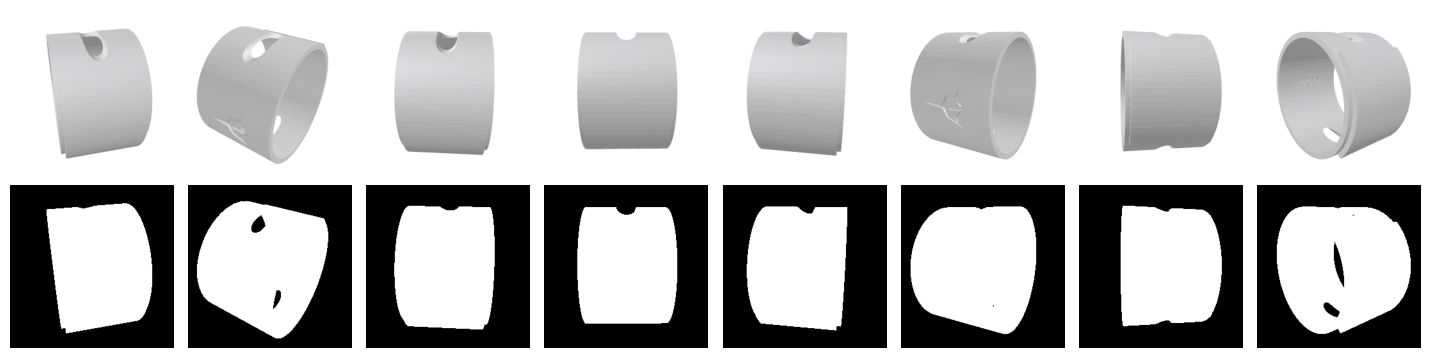

In [3]:
# Copy the shards from Drive to fast local disk (once per session) and open
# the datasets. These are notebook 03's shards, unchanged - this variant
# needs no rebuild, it only reads the posed views that are already there.
train_remote = shard_dir(cfg, f"{SPLIT_PREFIX}train")
val_remote = shard_dir(cfg, f"{SPLIT_PREFIX}test")
train_local = Path(cfg.local_root) / f"{SPLIT_PREFIX}train"
val_local = Path(cfg.local_root) / f"{SPLIT_PREFIX}test"
shards.prepare_local(train_remote, train_local, progress=tqdm)
shards.prepare_local(val_remote, val_local, progress=tqdm)

train_dataset = data.DesignDataset(train_local / "cache")
val_dataset = data.DesignDataset(val_local / "cache")
assert len(train_dataset) > 0, "no train shards found - run notebook 03 first (matching SMOKE)"
if len(val_dataset) == 0:
    val_dataset = train_dataset
    print("no test shards - using train designs for validation visuals")
print(f"train designs: {len(train_dataset)}   validation designs: {len(val_dataset)}")

demo = train_dataset[0]
print(f"{demo['design_id']}: {demo['meta']['n_views']} posed views "
      f"at {demo['views'].shape[1]}px")
fig = viz.show_view_grid(list(demo["views"][:8]), masks=list(demo["masks"][:8]))
plt.show()

## Drawing a render with two convolutions

Turning a shaded render into a line drawing takes no learning at all - two fixed convolutions and some arithmetic:

1. blur the grayscale image with a Gaussian, so that shading gradients and render noise stop looking like edges,
2. convolve with the Sobel pair to get the horizontal and vertical brightness derivatives,
3. take the magnitude of that gradient vector - large where brightness changes fast, which is exactly where a person would draw a line,
4. normalize, apply a contrast gain, and invert onto a light page.

The next cells run those steps one panel at a time.

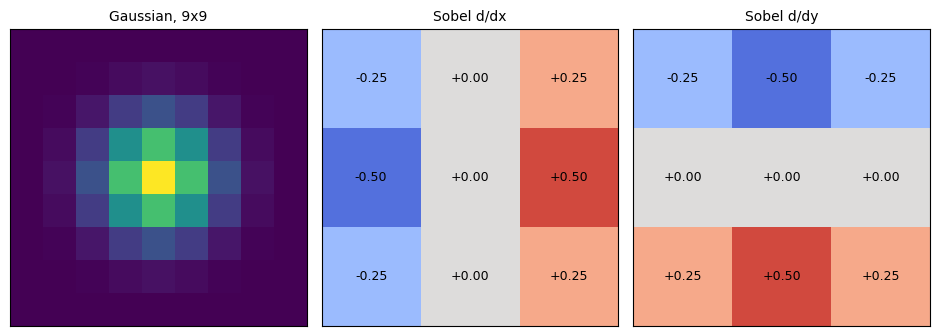

blur kernel sums to 1.000 (brightness preserved); each Sobel kernel sums to 0.000 (flat areas -> 0)


In [4]:
# The three kernels, drawn. The Gaussian is separable, so it is applied as
# two 1D passes; the Sobel pair is the classic 3x3 derivative stencil.
kernel_1d = synth.gaussian_kernel1d(cfg.edge_blur_sigma)
gaussian_2d = torch.outer(kernel_1d, kernel_1d)

fig, axes = plt.subplots(1, 3, figsize=(9.5, 3.4))
axes[0].imshow(gaussian_2d, cmap="viridis")
axes[0].set_title(f"Gaussian, {kernel_1d.numel()}x{kernel_1d.numel()}", fontsize=10)
for ax, kernel, title in zip(
    axes[1:], [synth.SOBEL_X[0, 0], synth.SOBEL_Y[0, 0]],
    ["Sobel d/dx", "Sobel d/dy"],
):
    ax.imshow(kernel, cmap="coolwarm", vmin=-0.6, vmax=0.6)
    for (r, c), value in np.ndenumerate(kernel.numpy()):
        ax.text(c, r, f"{value:+.2f}", ha="center", va="center", fontsize=9)
    ax.set_title(title, fontsize=10)
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
fig.tight_layout()
plt.show()
print(f"blur kernel sums to {float(kernel_1d.sum()):.3f} (brightness preserved); "
      f"each Sobel kernel sums to {float(synth.SOBEL_X.sum()):.3f} (flat areas -> 0)")

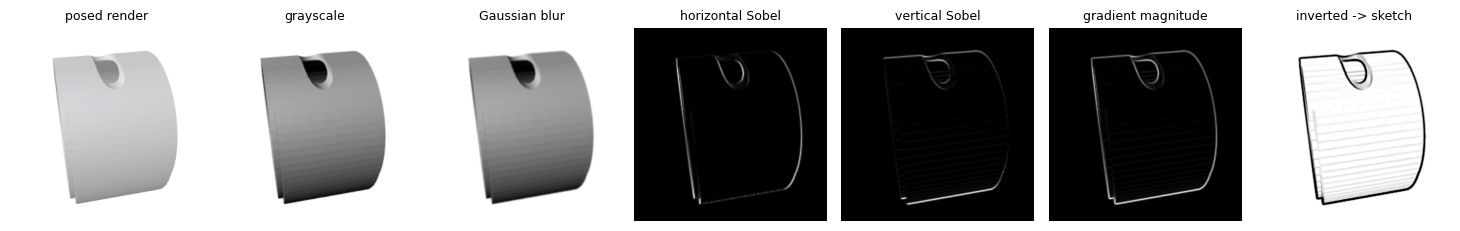

In [5]:
# The pipeline, one stage per panel, on a single view. Every step is a
# convolution or a per-pixel arithmetic op - no learned weights anywhere.
# Note the padding mode: replicating the edge pixels rather than padding
# with zeros, so the image border does not become an edge of its own.
demo_view = demo["views"][0]
x = torch.from_numpy(demo_view.astype(np.float32) / 255.0).permute(2, 0, 1)[None]
x = F.interpolate(
    x, (cfg.sketch_size, cfg.sketch_size), mode="bilinear",
    align_corners=False, antialias=True,
)
gray = 0.299 * x[:, 0:1] + 0.587 * x[:, 1:2] + 0.114 * x[:, 2:3]

radius = kernel_1d.numel() // 2
blurred = F.conv2d(
    F.pad(gray, (radius, radius, 0, 0), mode="replicate"),
    kernel_1d.reshape(1, 1, 1, -1),
)
blurred = F.conv2d(
    F.pad(blurred, (0, 0, radius, radius), mode="replicate"),
    kernel_1d.reshape(1, 1, -1, 1),
)

padded = F.pad(blurred, (1, 1, 1, 1), mode="replicate")
gx = F.conv2d(padded, synth.SOBEL_X)
gy = F.conv2d(padded, synth.SOBEL_Y)
magnitude = torch.sqrt(gx * gx + gy * gy + 1e-12)
magnitude = magnitude / magnitude.amax().clamp_min(1e-3)
edges = (cfg.edge_gain * magnitude).clamp(0, 1)
sketch = (cfg.edge_bg - edges * cfg.edge_bg).clamp(0, 1)

stages = [
    (demo_view, "posed render"),
    (gray[0, 0], "grayscale"),
    (blurred[0, 0], "Gaussian blur"),
    (gx[0, 0].abs(), "horizontal Sobel"),
    (gy[0, 0].abs(), "vertical Sobel"),
    (magnitude[0, 0], "gradient magnitude"),
    (sketch[0, 0], "inverted -> sketch"),
]
fig, axes = plt.subplots(1, len(stages), figsize=(2.1 * len(stages), 2.6))
for ax, (image, title) in zip(axes, stages):
    image = image if isinstance(image, np.ndarray) else image.numpy()
    ax.imshow(image, cmap=None if image.ndim == 3 else "gray")
    ax.set_title(title, fontsize=9)
    ax.axis("off")
fig.tight_layout()
plt.show()

In [6]:
# Cross-check: the package function the training loop calls must produce
# exactly the image built stage by stage above. It returns the drawing
# repeated into three channels, because the stock encoder wants RGB.
reference = synth.sobel_sketch(
    demo_view, cfg.sketch_size, cfg.edge_blur_sigma, cfg.edge_gain, cfg.edge_bg
)
delta = float((reference[0] - sketch[0, 0]).abs().max())
assert delta < 1e-6, f"package and notebook disagree by {delta}"
assert torch.equal(reference[0], reference[2])
print(f"starx.synth.sobel_sketch matches the cells above (max diff {delta:.2e})")
print("model input shape:", tuple(reference.shape),
      f"  range [{float(reference.min()):.2f}, {float(reference.max()):.2f}]")

starx.synth.sobel_sketch matches the cells above (max diff 0.00e+00)
model input shape: (3, 512, 512)   range [0.00, 1.00]


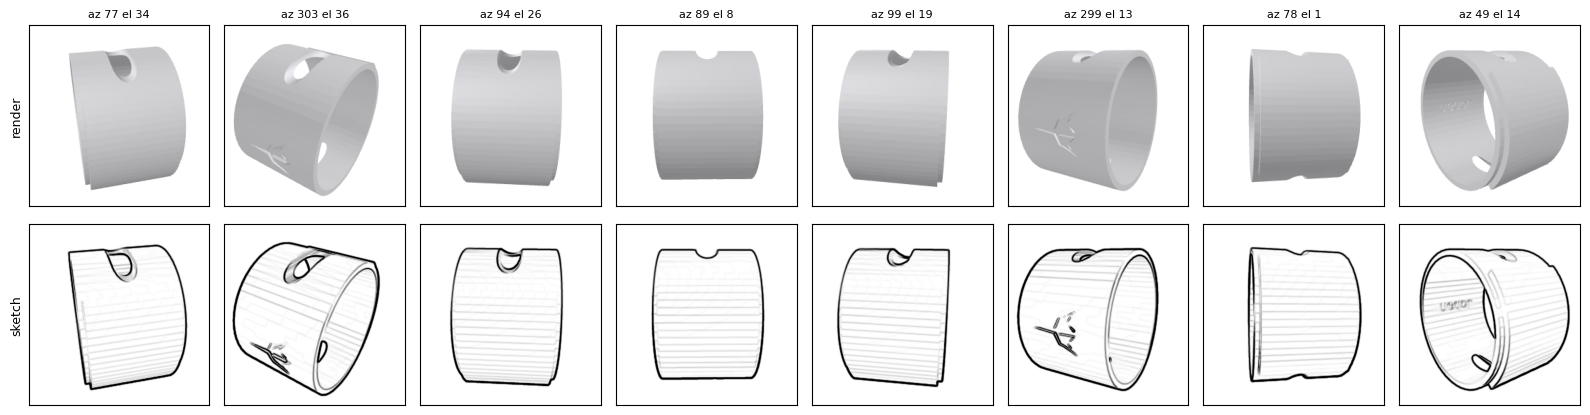

In [7]:
# The whole camera rig, drawn: every stored view of this design above its
# synthetic sketch. One design becomes as many training inputs as it has
# views, and each one is a different, self-consistent picture of the part.
n_show = 8
fig, axes = plt.subplots(2, n_show, figsize=(2.0 * n_show, 4.4))
for c in range(n_show):
    sketch = synth.sobel_sketch(
        demo["views"][c], cfg.sketch_size, cfg.edge_blur_sigma,
        cfg.edge_gain, cfg.edge_bg,
    )
    axes[0, c].imshow(demo["views"][c])
    axes[0, c].set_title(f"az {demo['meta']['view_angles'][c][0]:.0f}"
                         f" el {demo['meta']['view_angles'][c][1]:.0f}", fontsize=8)
    axes[1, c].imshow(sketch[0], cmap="gray", vmin=0, vmax=1)
for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])
axes[0, 0].set_ylabel("render", fontsize=9)
axes[1, 0].set_ylabel("sketch", fontsize=9)
fig.tight_layout()
plt.show()

## Choosing the two knobs

Only two numbers shape the result. The blur width sets what counts as an edge: too little and shading gradients and render noise become strokes, too much and real creases thin out or vanish. The contrast gain sets how aggressively weak gradients are pushed to full black, which is the difference between a faint pencil sketch and a heavy marker drawing.

Pick them by eye on real designs - the drawing should keep the silhouette and the visible creases, and leave the flat faces blank.

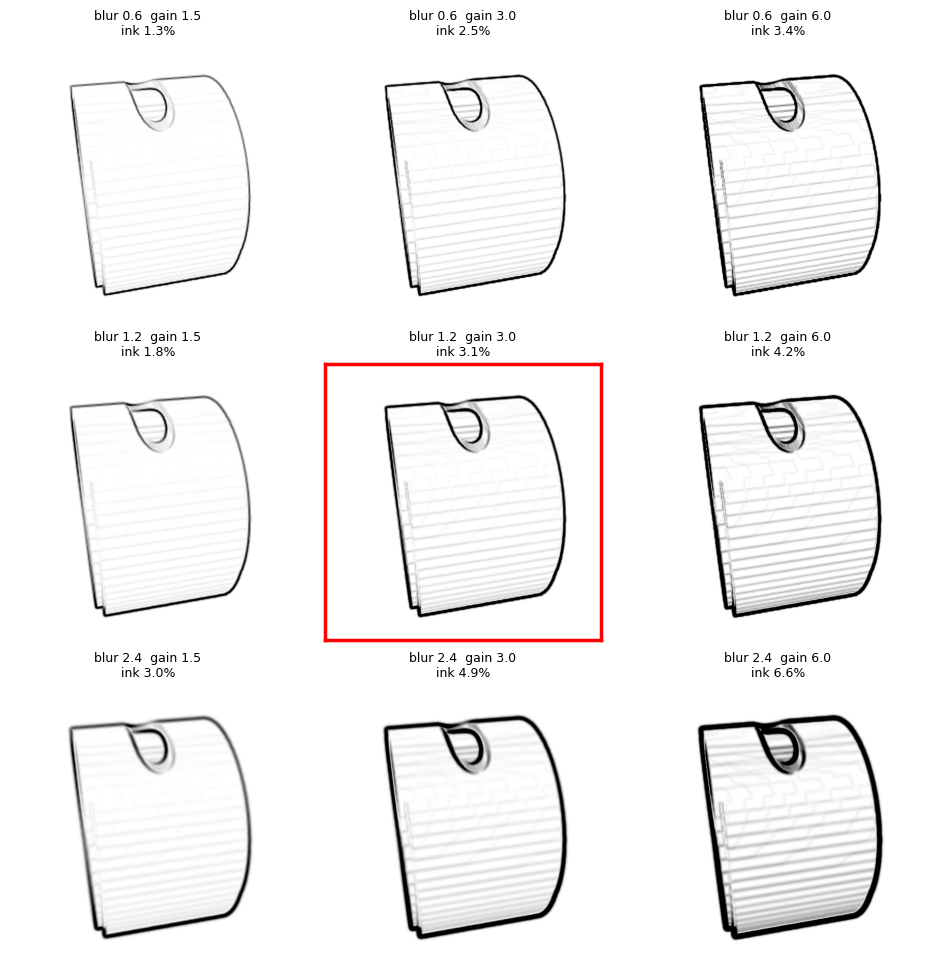

In [8]:
# Sweep the two knobs on one view. Blur decides how much surface texture
# survives into the gradient; gain decides how dark a weak edge gets drawn.
# The red frame marks the configured combination; "ink" is the fraction of
# the page darker than mid-gray - a rough stand-in for stroke weight.
sigmas = [0.6, 1.2, 2.4]
gains = [1.5, 3.0, 6.0]

fig, axes = plt.subplots(len(sigmas), len(gains), figsize=(9.6, 9.8))
for r, sigma in enumerate(sigmas):
    for c, gain in enumerate(gains):
        candidate = synth.sobel_sketch(
            demo_view, cfg.sketch_size, sigma, gain, cfg.edge_bg
        )[0].numpy()
        ink = float((candidate < 0.5).mean())
        ax = axes[r, c]
        ax.imshow(candidate, cmap="gray", vmin=0, vmax=1)
        ax.set_title(f"blur {sigma}  gain {gain}\nink {ink:.1%}", fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])
        chosen = sigma == cfg.edge_blur_sigma and gain == cfg.edge_gain
        for spine in ax.spines.values():
            spine.set_edgecolor("red" if chosen else "none")
            spine.set_linewidth(2.5)
fig.tight_layout()
plt.show()

## Where the object is facing

TripoSR takes no camera input. It reconstructs in the frame of whatever picture it is given: the object comes out facing the input view, because that is how its pretraining data was built.

That matters here in a way it did not for the baseline. The input is now a picture taken from a specific viewpoint, and the ground-truth views it will be scored against were rendered in the mesh's own frame. Supervising directly would ask the model to output a rotation it has no way to know, and the cheapest way to satisfy that demand is a shapeless blob that looks equally mediocre from every angle.

The fix is free: rotate the world about the vertical axis so the input camera sits at azimuth zero, and express every supervision camera in that rotated world. No pixel changes - a rigid rotation of the whole rig - but now the frame the model predicts in and the frame it is scored in are the same one.

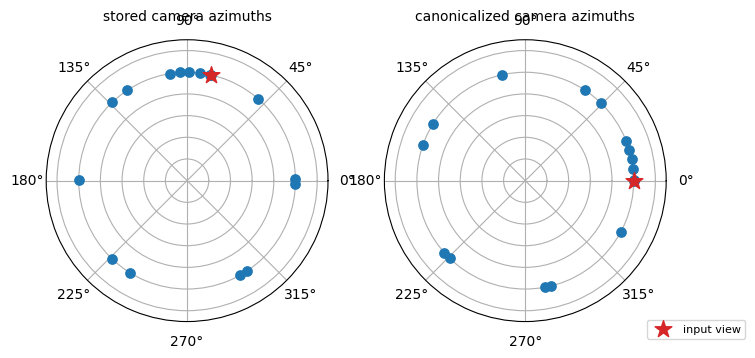

input camera azimuth: +77.4 deg -> +0.0 deg
all camera-to-camera distances preserved: the rig turned, not the object


In [9]:
# Rotate the world about z until the input camera sits at azimuth zero.
# The renders are untouched - only the matrices move - so this costs
# nothing and can be verified two ways: the input camera lands at zero,
# and every camera-to-camera distance is preserved (a rigid rotation).
INPUT_VIEW = 0
demo_angles = np.asarray(demo["meta"]["view_angles"])
stored_c2ws = np.asarray(demo["c2ws"])
demo_c2ws = synth.canonicalize_to_view(stored_c2ws, demo_angles[INPUT_VIEW, 0])


def azimuths_of(c2ws):
    """Recover each camera's azimuth from its position, in (-180, 180] deg."""
    raw = np.degrees(np.arctan2(c2ws[:, 1, 3], c2ws[:, 0, 3]))
    return (raw + 180.0) % 360.0 - 180.0


def pairwise_distances(c2ws):
    return np.linalg.norm(c2ws[:, None, :3, 3] - c2ws[None, :, :3, 3], axis=-1)


before = azimuths_of(stored_c2ws)
after = azimuths_of(demo_c2ws)
assert abs(after[INPUT_VIEW]) < 1e-3, "input camera did not land at azimuth zero"
moved = np.abs(
    pairwise_distances(stored_c2ws) - pairwise_distances(demo_c2ws)
).max()
assert moved < 1e-4, f"the rotation was not rigid (distances moved by {moved})"

fig, axes = plt.subplots(1, 2, figsize=(8, 4), subplot_kw={"projection": "polar"})
for ax, angles, title in zip(axes, [before, after], ["stored", "canonicalized"]):
    ax.scatter(np.radians(angles), np.ones_like(angles), s=45,
               color=plt.get_cmap("tab10").colors[0], zorder=3)
    ax.scatter(np.radians(angles[INPUT_VIEW]), 1.0, s=160, marker="*",
               color=plt.get_cmap("tab10").colors[3], zorder=4, label="input view")
    ax.set_yticklabels([])
    ax.set_ylim(0, 1.3)
    ax.set_title(f"{title} camera azimuths", fontsize=10, pad=14)
axes[1].legend(loc="lower right", bbox_to_anchor=(1.3, -0.08), fontsize=8)
plt.show()
print(f"input camera azimuth: {before[INPUT_VIEW]:+.1f} deg -> {after[INPUT_VIEW]:+.1f} deg")
print("all camera-to-camera distances preserved: the rig turned, not the object")

## The model: stock TripoSR, no surgery

Notebook 04 rebuilt the patch embedding to swallow a stack of sketch channels and rewrote the tokenizer's normalization buffers to match. None of that happens here. The sketch is a three-channel image of an object seen from a viewpoint - the same kind of thing the checkpoint was pretrained on - so the pretrained encoder is left exactly as it shipped and only the adapters are added.

That keeps the comparison honest: any difference against the baseline run comes from the input representation and the camera convention, not from a modified network.

In [10]:
# Build the model and prove nothing was cut: the patch embedding still has
# three input slots and the tokenizer still holds its pretrained ImageNet
# statistics. Then the usual memory settings - gradient checkpointing on,
# render chunking off (under autograd the memory lever is crop size).
model, build_info = smodel.build_stock_lora_model(
    cfg, TRIPOSR_DIR, device=device, full_finetune=FULL_FINETUNE
)
projection = model.image_tokenizer.model.embeddings.patch_embeddings.projection
assert projection.in_channels == 3, "this notebook must run the unmodified encoder"
print(projection)
print("normalization mean/std:",
      [round(v, 3) for v in model.image_tokenizer.image_mean.flatten().tolist()],
      [round(v, 3) for v in model.image_tokenizer.image_std.flatten().tolist()])

model.image_tokenizer.model.gradient_checkpointing_enable()
model.backbone.gradient_checkpointing = True
model.renderer.set_chunk_size(0)

trainable_params = [p for p in model.parameters() if p.requires_grad]
totals = build_info["param_table"]["ALL"]
print(f"trainable: {totals['trainable']:,} of {totals['total']:,} "
      f"({100 * totals['trainable'] / totals['total']:.2f}%)")
print("lora modules:", build_info["lora_counts"] or "none (full fine-tune)")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.yaml:   0%|          | 0.00/987 [00:00<?, ?B/s]

model.ckpt: reconstructing file:   0%|          |  0.00B / 1.68GB            

model.ckpt: downloading bytes:           |  0.00B            

config.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
normalization mean/std: [0.485, 0.456, 0.406] [0.229, 0.224, 0.225]
trainable: 4,948,736 of 423,633,772 (1.17%)
lora modules: {'dino_lora_modules': 12, 'backbone_lora_modules': 128}


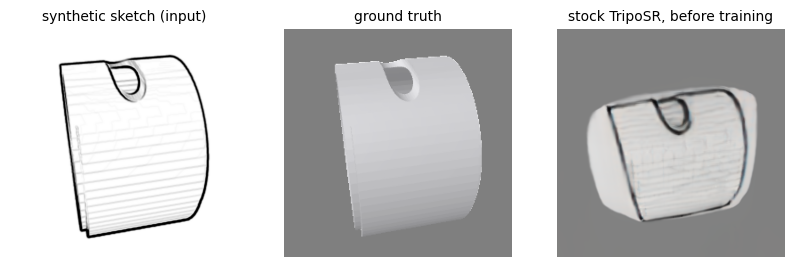

In [11]:
# The "before" picture: what the pretrained checkpoint already does with a
# synthetic sketch, rendered from the input view's own camera. LoRA is an
# identity at initialization (its B matrices start at zero), so this is
# literally stock TripoSR. Expect something object-shaped but wrong - that
# is the starting point the training loop improves on.
demo_sketch = synth.sobel_sketch(
    demo["views"][0], cfg.sketch_size, cfg.edge_blur_sigma, cfg.edge_gain, cfg.edge_bg
)
model.eval()
model.renderer.set_chunk_size(cfg.eval_chunk)
with torch.no_grad():
    with torch.autocast("cuda", dtype=AMP_DTYPE, enabled=device == "cuda"):
        demo_code = smodel.encode_sketches(model, demo_sketch[None].to(device))[0]
    rays_o, rays_d = cameras.rays_full(demo_c2ws[0], FOVY_DEG, cfg.gt_size)
    rgb_fg, opacity = strain.render_rays(
        model, demo_code.float(), rays_o.to(device), rays_d.to(device)
    )
pred = strain.composite_over_gray(rgb_fg, opacity).clamp(0, 1).cpu().numpy()
model.renderer.set_chunk_size(0)
model.train()

gt = demo["views"][0].astype(np.float32) / 255.0
gt = np.where(demo["masks"][0][..., None], gt, 0.5)
fig, axes = plt.subplots(1, 3, figsize=(10, 3.6))
for ax, image, title in zip(
    axes,
    [demo_sketch[0].numpy(), gt, pred],
    ["synthetic sketch (input)", "ground truth", "stock TripoSR, before training"],
):
    ax.imshow(image, cmap="gray" if image.ndim == 2 else None, vmin=0, vmax=1)
    ax.set_title(title, fontsize=10)
    ax.axis("off")
plt.show()

## Training

The recipe is notebook 05's, unchanged: encode the input into a triplane scene code, render small foreground-biased crops of it at the ground-truth cameras with the differentiable ray march, and score them with pixel MSE, perceptual LPIPS, and a mask term on opacity, plus the 3D visual-hull Dice term. Memory discipline is the same two-stage backward, and checkpoints resume the same way.

Only the first line of the step differs, and it is passed in as a hook: instead of the design's channel-stacked sketch and its stored cameras, this run feeds one view's edge sketch and the cameras rotated into that view's frame. The loss never learns it is looking at a variant.

In [12]:
# Optimizer, schedule, and the frozen VGG that scores the perceptual loss -
# all from starx.train, identical to the baseline run.
from torchmetrics.image import LearnedPerceptualImagePatchSimilarity

optimizer, scheduler = strain.build_optimizer(model, trainable_params, cfg)

lpips_metric = LearnedPerceptualImagePatchSimilarity(net_type="vgg", normalize=True)
lpips_metric = lpips_metric.to(device).requires_grad_(False)
lpips_metric.eval()
group_sizes = [sum(p.numel() for p in g["params"]) for g in optimizer.param_groups]
print(f"param groups (no decay, decay): {group_sizes[0]:,} / {group_sizes[1]:,}")

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:04<00:00, 125MB/s]


param groups (no decay, decay): 4,358,144 / 590,592


In [13]:
# The one line that makes this variant a variant: an input hook handed to
# the shared training step. It picks the input view, edge-detects it, and
# canonicalizes the cameras - everything after it is notebook 05's step.
input_fn = synth.make_input_fn(cfg, device)
probe_input, probe_c2ws = input_fn(demo, step=0)
print("model input:", tuple(probe_input.shape), probe_input.dtype)
print("supervision cameras:", probe_c2ws.shape)

picked = [
    synth.pick_input_view(demo["design_id"], s, demo["meta"]["n_views"], cfg.seed)
    for s in range(12)
]
print("input view chosen at steps 0..11:", picked)
print("every view eventually serves as the input - free augmentation, "
      f"{demo['meta']['n_views']} inputs per design")


def train_step(step):
    return strain.train_step(
        step, model, train_dataset, optimizer, scheduler, trainable_params,
        lpips_metric, cfg, device, AMP_DTYPE, GRAD_SCALE, input_fn=input_fn,
    )

model input: (1, 3, 512, 512) torch.float32
supervision cameras: (16, 4, 4)
input view chosen at steps 0..11: [14, 1, 1, 14, 1, 14, 14, 1, 0, 15, 8, 7]
every view eventually serves as the input - free augmentation, 16 inputs per design


In [14]:
# Resume: restore the newest checkpoint for this run name - model,
# optimizer, schedule, and random state - or start fresh.
rdir = run_dir(cfg, RUN_NAME)
latest = checkpoint.find_latest(rdir) if RESUME else None
if latest is not None:
    ckpt_path, start_step = latest
    state = checkpoint.load_checkpoint(ckpt_path)
    smodel.load_trainable_state_dict(model, state["model"])
    optimizer.load_state_dict(state["optimizer"])
    scheduler.load_state_dict(state["scheduler"])
    checkpoint.restore_rng(state["rng"])
    print(f"resumed {RUN_NAME} at step {start_step}")
else:
    start_step = 0
    print(f"starting {RUN_NAME} fresh")

starting synth_edges fresh


  0%|          | 0/20000 [00:00<?, ?it/s]

/content/StarX/starx/train.py:105: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  "mse": float(mse),


first step: 52.4s
peak VRAM: 7.9 GiB


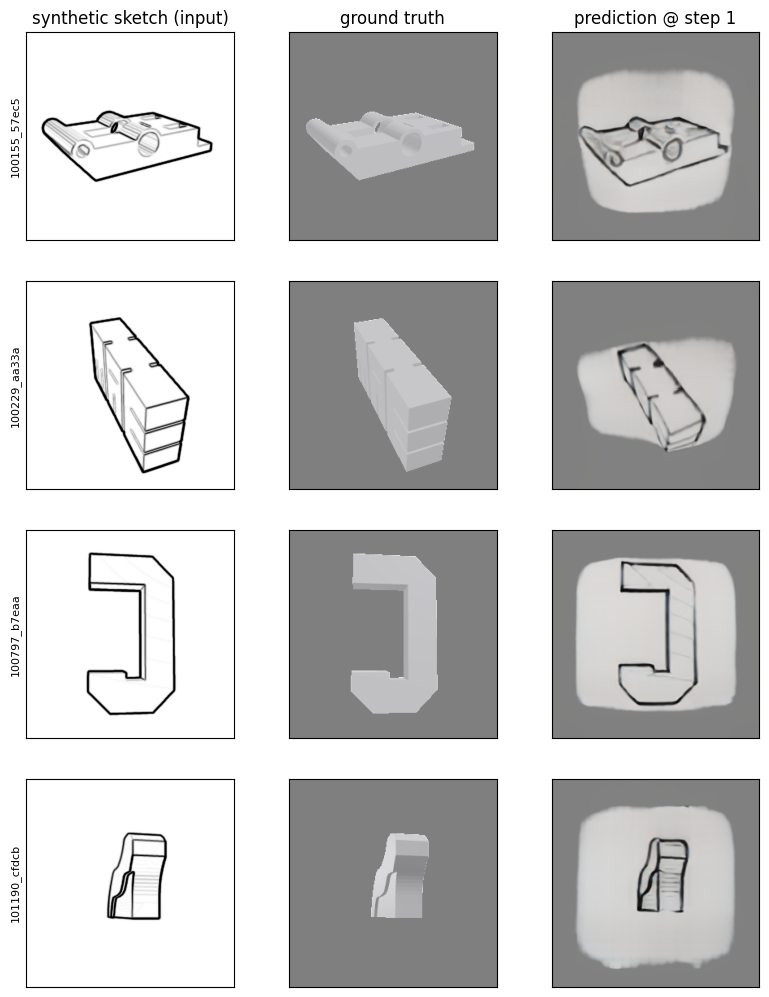

In [ ]:
# The loop. Everything before was preparation; this cell can run for hours
# and can be killed and re-run at any time - it resumes automatically.
# A validation grid renders right after the first step of every session,
# then every interval after; the first step also prints its time and the
# VRAM peak so a speed or memory problem surfaces in seconds, not hours.
log_path = rdir / "logs" / "train_log.jsonl"
grid_dir = rdir / "val_grids"
grid_dir.mkdir(parents=True, exist_ok=True)
val_items = [val_dataset[i] for i in range(min(4, len(val_dataset)))]


def render_val_grid(items, step):
    """Sketch | ground truth | current prediction, one row per design.

    Validation always uses each design's view 0 as the input, so the rows
    are comparable across steps (training keeps rotating the input view).
    """
    model.eval()
    model.renderer.set_chunk_size(cfg.eval_chunk)
    fig, axes = plt.subplots(len(items), 3, figsize=(9.6, 3.1 * len(items)))
    axes = np.atleast_2d(axes)
    with torch.no_grad():
        for row, item in enumerate(items):
            sketch = synth.sobel_sketch(
                item["views"][0], cfg.sketch_size, cfg.edge_blur_sigma,
                cfg.edge_gain, cfg.edge_bg,
            )
            view_c2ws = synth.canonicalize_to_view(
                item["c2ws"], item["meta"]["view_angles"][0][0]
            )
            with torch.autocast("cuda", dtype=AMP_DTYPE, enabled=device == "cuda"):
                code = smodel.encode_sketches(model, sketch[None].to(device))[0]
            code = code.float()
            rays_o, rays_d = cameras.rays_full(view_c2ws[0], FOVY_DEG, cfg.gt_size)
            rgb_fg, opacity = strain.render_rays(
                model, code, rays_o.to(device), rays_d.to(device)
            )
            pred = strain.composite_over_gray(rgb_fg, opacity).clamp(0, 1).cpu().numpy()
            gt = item["views"][0].astype(np.float32) / 255.0
            gt = np.where(item["masks"][0][..., None], gt, 0.5)
            axes[row, 0].imshow(sketch[0], cmap="gray", vmin=0, vmax=1)
            axes[row, 1].imshow(gt)
            axes[row, 2].imshow(pred)
            axes[row, 0].set_ylabel(item["design_id"][:12], fontsize=8)
    for ax in axes.ravel():
        ax.set_xticks([])
        ax.set_yticks([])
    axes[0, 0].set_title("synthetic sketch (input)")
    axes[0, 1].set_title("ground truth")
    axes[0, 2].set_title(f"prediction @ step {step}")
    model.renderer.set_chunk_size(0)
    model.train()
    return fig


progress = tqdm(
    range(start_step, cfg.total_steps), initial=start_step, total=cfg.total_steps
)
for step in progress:
    step_started = time.time()
    totals = train_step(step)
    if step == start_step:
        print(f"first step: {time.time() - step_started:.1f}s")
        if device == "cuda":
            print(f"peak VRAM: {torch.cuda.max_memory_allocated() / 2**30:.1f} GiB")
    progress.set_postfix(loss=f"{totals['loss']:.3f}")
    completed = step + 1
    if completed % 50 == 0 or completed == cfg.total_steps:
        checkpoint.append_log(log_path, {"step": completed, **totals})
    if completed % cfg.ckpt_every == 0 or completed == cfg.total_steps:
        checkpoint.save_checkpoint(
            rdir,
            completed,
            {
                "model": smodel.trainable_state_dict(model),
                "optimizer": optimizer.state_dict(),
                "scheduler": scheduler.state_dict(),
                "rng": checkpoint.rng_states(),
            },
            keep_k=cfg.keep_k,
        )
    if (
        completed % cfg.val_every == 0
        or completed == cfg.total_steps
        or completed == start_step + 1
    ):
        fig = render_val_grid(val_items, completed)
        fig.savefig(grid_dir / f"step_{completed:07d}.png", dpi=110, bbox_inches="tight")
        plt.show()
print("training loop finished")

In [ ]:
# The full training history: loss terms (log scale) and the LR schedule.
history = checkpoint.read_log(log_path)
fig = viz.plot_loss_curves(history, keys=("loss", "mse", "lpips", "mask", "occ"))
plt.show()

fig, ax = plt.subplots(figsize=(9, 2.6))
ax.plot(history["step"], history["lr"], color=plt.get_cmap("tab10").colors[4])
ax.set_xlabel("step")
ax.set_ylabel("learning rate")
ax.grid(alpha=0.3)
plt.show()

In [ ]:
# Before and after: the loop saved a validation grid every interval - the
# first and the last tell the story of the run.
from PIL import Image

grids = sorted(grid_dir.glob("step_*.png"))
if len(grids) >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.6))
    for ax, path in zip(axes, [grids[0], grids[-1]]):
        ax.imshow(Image.open(path))
        ax.set_title(path.stem)
        ax.axis("off")
    plt.show()
else:
    print(f"{len(grids)} grid(s) saved so far - train longer to compare")

## Reading the results

The validation grids are the honest signal: the prediction should sharpen from a gray cloud toward the silhouette in the ground-truth column, and the loss terms should fall together.

Two comparisons make this notebook worth running. Against the surgered baseline, it isolates how much of that run's difficulty came from the channel-stacked input: this model sees an ordinary picture from a known viewpoint, which is exactly the setting the checkpoint was pretrained for, so if it also collapses the problem is the supervision, not the input representation. Against the pretrained-on-thumbnails anchor, it measures what fine-tuning on line drawings buys over feeding the frozen model a shaded photograph.

Notebook 06 measures both properly - point this notebook's run name at its evaluation and swap the input builder for the edge sketch used here.